# Shendure Geneformer — MI vs training step

For every shendure × Geneformer run we computed MI at 20 evenly-spaced checkpoints. This notebook scans the per-checkpoint `lmi_mutual_information.txt` files under

```
data/shendure/<size>/<quality>/results/Geneformer/checkpoint-NNNN/MI/42/Y_author_day_<quality>_geneformer/
```

builds a long-form DataFrame, and plots MI vs optimizer step — one row per size, one viridis-colored line per quality. Outputs: `shendure_geneformer_checkpoint_mi.csv` + `.png` in `analysis/final_results/`.

Layout mirrors `2026-04-18_09-49_plotting_loss_curves_all_algos.ipynb` (rows = sizes, viridis = quality), stripped down to the single MI panel. Axes are linear-linear (not log).

In [25]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_ROOT = Path('/home/igor/noise_scaling/data')
DATASET = 'shendure'
ALGO = 'Geneformer'
SIGNAL = 'author_day'
SEED = 42

FINAL_RESULTS_DIR = Path('/home/igor/noise_scaling/Scaling-up-measurement-noise-scaling-laws/analysis/final_results')
FINAL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
OUT_CSV = FINAL_RESULTS_DIR / 'shendure_geneformer_checkpoint_mi.csv'
OUT_PNG = FINAL_RESULTS_DIR / 'shendure_geneformer_checkpoint_mi.png'

FIG_DPI = 300
PER_ROW_H = 2.2

_CKPT_RE = re.compile(r'^checkpoint-(\d+)$')

In [26]:
# Walk the shendure/Geneformer tree and collect MI values from per-checkpoint files.

def _read_mi(p: Path):
    try:
        return float(p.read_text().strip())
    except Exception:
        return None

rows = []
ds_root = DATA_ROOT / DATASET
size_dirs = sorted((p for p in ds_root.iterdir() if p.is_dir() and p.name.isdigit()), key=lambda p: int(p.name))
for size_dir in size_dirs:
    size = int(size_dir.name)
    quality_dirs = []
    for p in size_dir.iterdir():
        if not p.is_dir():
            continue
        try:
            float(p.name)
            quality_dirs.append(p)
        except ValueError:
            pass
    quality_dirs.sort(key=lambda p: float(p.name))
    for q_dir in quality_dirs:
        q_str = q_dir.name
        q_val = float(q_str)
        gf_dir = q_dir / 'results' / ALGO
        if not gf_dir.is_dir():
            continue
        signal_stem = f'Y_{SIGNAL}_{q_str}_geneformer'
        for ckpt_dir in gf_dir.iterdir():
            m = _CKPT_RE.match(ckpt_dir.name)
            if not m:
                continue
            step = int(m.group(1))
            mi_path = ckpt_dir / 'MI' / str(SEED) / signal_stem / 'lmi_mutual_information.txt'
            if not mi_path.exists():
                continue
            mi = _read_mi(mi_path)
            if mi is None:
                continue
            rows.append({
                'dataset': DATASET,
                'algo': ALGO,
                'signal': SIGNAL,
                'seed': SEED,
                'size': size,
                'quality': q_val,
                'quality_str': q_str,
                'step': step,
                'mi': mi,
            })

mi_df = pd.DataFrame(rows).sort_values(['size', 'quality', 'step']).reset_index(drop=True)
mi_df.to_csv(OUT_CSV, index=False)
print(f'Collected {len(mi_df):,} MI rows across {mi_df["size"].nunique()} sizes, {mi_df["quality"].nunique()} qualities.')
print(f'Wrote {OUT_CSV}')
mi_df.head()

Collected 191 MI rows across 10 sizes, 10 qualities.
Wrote /home/igor/noise_scaling/Scaling-up-measurement-noise-scaling-laws/analysis/final_results/shendure_geneformer_checkpoint_mi.csv


,dataset,algo,signal,seed,size,quality,quality_str,step,mi
0,shendure,Geneformer,author_day,42,100,0.004000,0.004,1000,0.16247
1,shendure,Geneformer,author_day,42,100,0.007387,0.0073875,1000,0.25233
2,shendure,Geneformer,author_day,42,100,0.007387,0.0073875,2000,0.21959
3,shendure,Geneformer,author_day,42,100,0.007387,0.0073875,3000,0.12643
4,shendure,Geneformer,author_day,42,100,0.007387,0.0073875,4000,0.15567


Saved figure to /home/igor/noise_scaling/Scaling-up-measurement-noise-scaling-laws/analysis/final_results/shendure_geneformer_checkpoint_mi.png


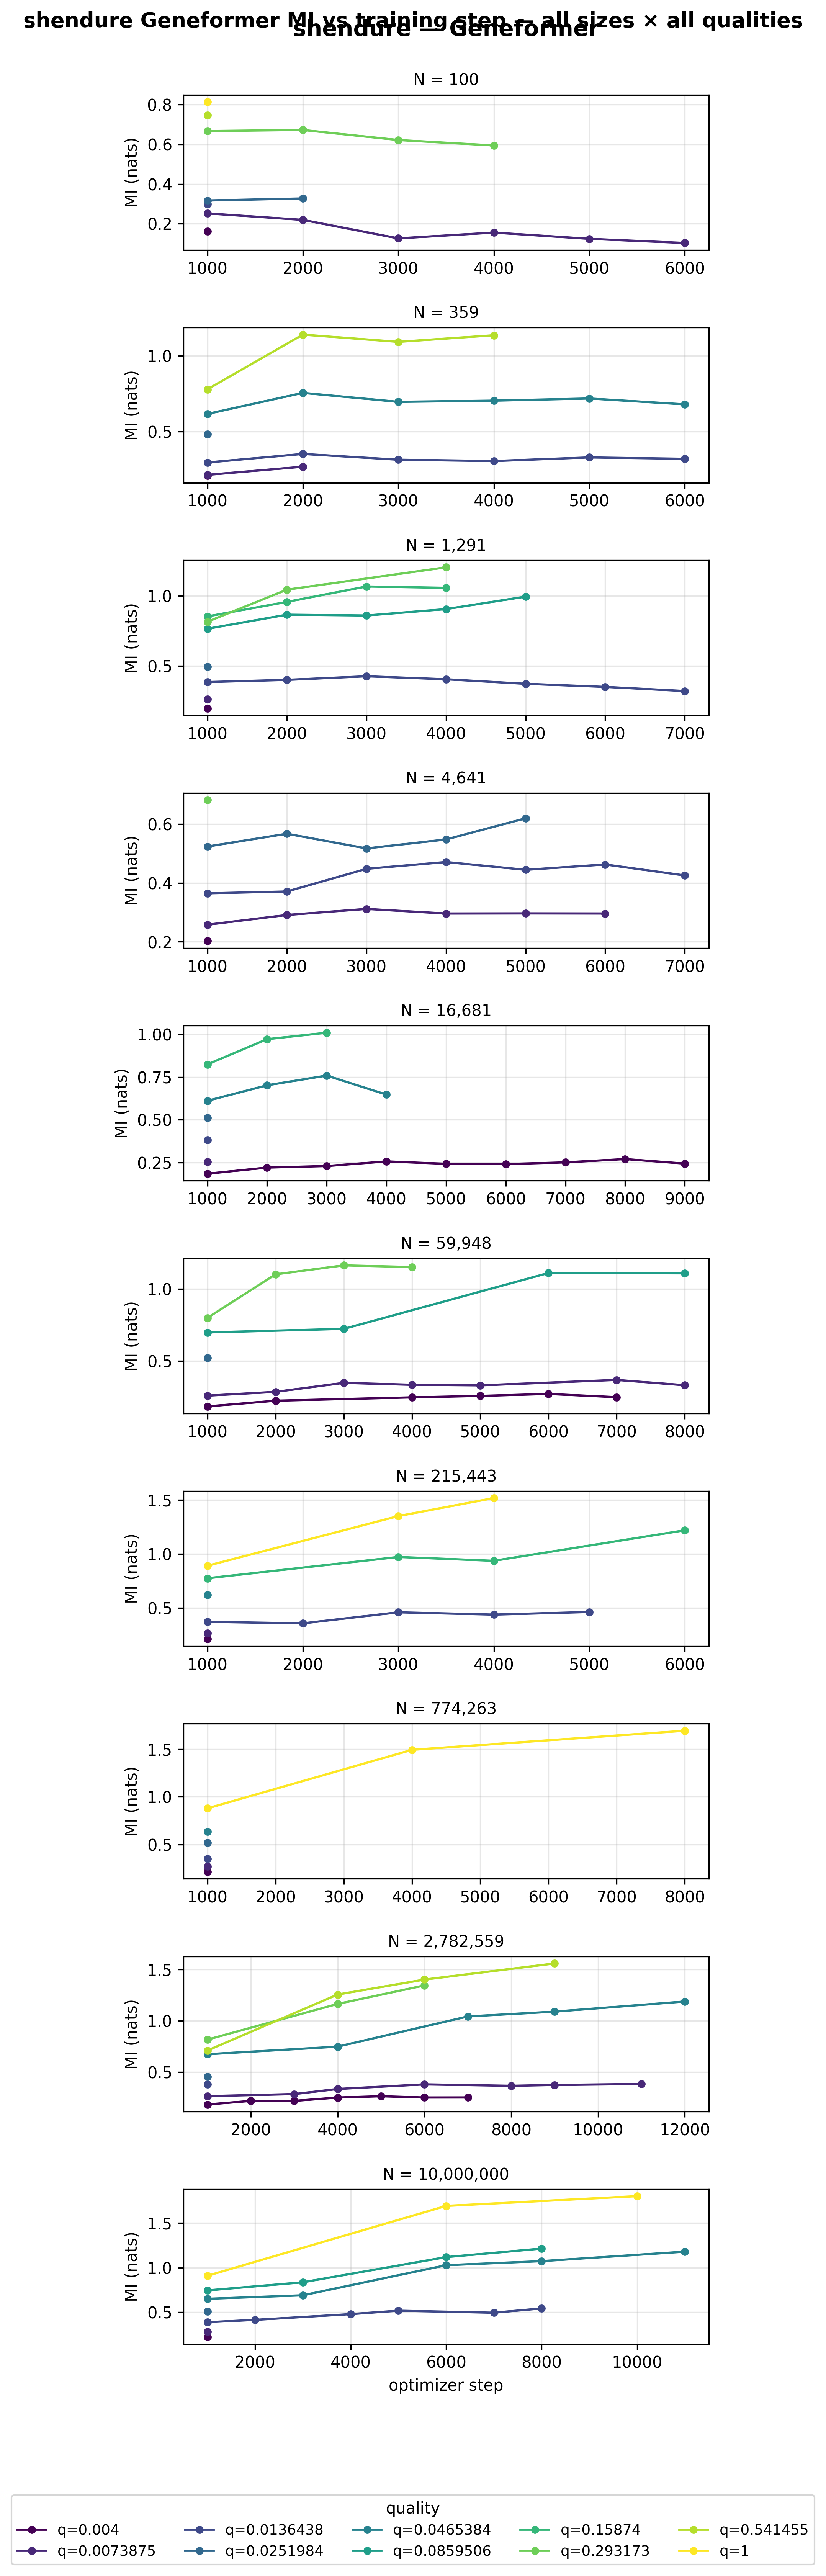

In [27]:
# One column, one row per size. Viridis colors quality (log10). X = optimizer step, Y = MI.
# Linear-linear axes — no log scaling.

df = pd.read_csv(OUT_CSV)
sizes = sorted(df['size'].unique())
qualities = sorted(df['quality'].unique())

nrows = len(sizes)
fig, axes = plt.subplots(
    nrows, 1,
    figsize=(5.5, PER_ROW_H * nrows),
    dpi=FIG_DPI, squeeze=False,
)
cmap = plt.get_cmap('viridis')
qnorm = (plt.Normalize(np.log10(min(qualities)), np.log10(max(qualities)))
         if len(qualities) > 1 else plt.Normalize(0, 1))

axes[0, 0].annotate(
    f'{DATASET} — {ALGO}', xy=(0.5, 1.35), xycoords='axes fraction',
    ha='center', va='bottom', fontsize=14, fontweight='bold',
)

for i, size in enumerate(sizes):
    ax = axes[i, 0]
    sub = df[df['size'] == size]
    if sub.empty:
        ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes, color='gray')
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f'N = {size:,}', fontsize=10)
        continue
    for q in sorted(sub['quality'].unique()):
        color = cmap(qnorm(np.log10(q))) if len(qualities) > 1 else cmap(0.5)
        qs = sub[sub['quality'] == q].sort_values('step')
        ax.plot(qs['step'], qs['mi'],
                color=color, marker='o', linewidth=1.4, markersize=4, label=f'q={q:g}')
    ax.grid(alpha=0.3)
    ax.set_title(f'N = {size:,}', fontsize=10)
    ax.set_ylabel('MI (nats)')
    if i == nrows - 1:
        ax.set_xlabel('optimizer step')

seen: dict[str, object] = {}
for ax in axes.flat:
    for h, l in zip(*ax.get_legend_handles_labels()):
        if l not in seen:
            seen[l] = h
def _q(label: str) -> float:
    try:
        return float(label.split('=', 1)[1])
    except Exception:
        return float('inf')
items = sorted(seen.items(), key=lambda kv: _q(kv[0]))
handles = [h for _, h in items]
labels = [l for l, _ in items]

plt.suptitle(
    f'{DATASET} Geneformer MI vs training step — all sizes × all qualities',
    y=1.003, fontsize=13, fontweight='bold',
)
plt.tight_layout()
plt.subplots_adjust(top=0.97, hspace=0.5, bottom=0.08)

fig.legend(
    handles, labels,
    loc='lower center', bbox_to_anchor=(0.5, -0.01),
    ncol=min(len(handles), 5), fontsize=9, title='quality', frameon=True,
)

fig.savefig(OUT_PNG, dpi=FIG_DPI, bbox_inches='tight')
print(f'Saved figure to {OUT_PNG}')
plt.show()

In [28]:
# Coverage table: checkpoints loaded per (size, quality), with MI range.
df = pd.read_csv(OUT_CSV)
summary = (
    df.groupby(['size', 'quality'])
      .agg(n_ckpts=('step', 'count'), step_min=('step', 'min'), step_max=('step', 'max'),
           mi_min=('mi', 'min'), mi_max=('mi', 'max'))
      .reset_index()
      .sort_values(['size', 'quality'])
)
print(f'{len(summary)} (size, quality) pairs with MI data — expected up to 20 ckpts per pair.')
summary

62 (size, quality) pairs with MI data — expected up to 20 ckpts per pair.


,size,quality,n_ckpts,step_min,step_max,mi_min,mi_max
0,100,0.004000,1,1000,1000,0.16247,0.16247
1,100,0.007387,6,1000,6000,0.10333,0.25233
2,100,0.013644,1,1000,1000,0.29976,0.29976
3,100,0.025198,2,1000,2000,0.31729,0.32758
4,100,0.293173,4,1000,4000,0.59443,0.67249
...,...,...,...,...,...,...,...
57,10000000,0.013644,6,1000,8000,0.38615,0.54104
58,10000000,0.025198,1,1000,1000,0.50774,0.50774
59,10000000,0.046538,5,1000,11000,0.64927,1.17879
60,10000000,0.085951,4,1000,8000,0.74372,1.21342
